In [ ]:
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
load_dotenv()

True

#tools binding, native tool by lang chain

In [11]:
#tool-1
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()
search.invoke("obama's mother name?")
#this is the same as we do google search
#this is one tool



"Stanley Ann Dunham was the mother of Barack Obama, and she died more than a decade before he became president of the United States. She was an anthropologist who raised her two biracial children as a single mother while pursuing her dreams of helping to create sustainable business models for women in rural Indonesian villages. Barack Obama's parents married while students at the University of Hawaii. His father, Barack Obama, Sr., a Kenyan, became an economist in the government of Kenya. His mother, S. Ann Dunham, became an anthropologist. They divorced in 1964. Ann then married (and later divorced) another foreign student, Indonesian Lolo Soetoro. Barack Obama, the 44th President of the United States, entered the world on August 4, 1961, in Honolulu, Hawaii, to a pair of young parents from vastly different backgrounds. His ethnicity, a mix of African heritage from his father and European-American roots from his mother, made him a symbol of America's evolving multicultural identity. T

In [12]:
#tool-2
#so now issue is that who gtp will know , this is the information and i have to go this tool. for this 
#we create the custome tool and bind  all tools in that and guide tool
import wikipedia

from langchain_community.tools import  WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia = WikipediaQueryRun (api_wrapper=WikipediaAPIWrapper ())
#print(wikipedia.invoke("Sam Altman"))
print(wikipedia.summary("Sam Altman", sentences=2))

AttributeError: 'WikipediaQueryRun' object has no attribute 'summary'

In [13]:
from langchain.tools import tool

In [14]:
@tool
def tool_duck_duck_go_search(query:str) -> str:
    """use  this tool when we need to answer questions about current events
    what is happening in current time, news and event around the world """
    #tool-A
    from langchain_community.tools import DuckDuckGoSearchRun
    search=DuckDuckGoSearchRun()
    response=search.invoke(query)
    return response

In [15]:
tool_duck_duck_go_search.invoke("what is the name of Founder of Pakistan")

"Muhammad Ali Jinnah[a] (born Mahomedali Jinnahbhai; [b] 25 December 1876 - 11 September 1948) was a barrister, statesman, and the founder of Pakistan. Jinnah served as the leader of the All-India Muslim League from 1913 until the inception of Pakistan on 14 August 1947, and then as Pakistan 's first governor-general until his death a year ... The history of Pakistan preceding the country's independence in 1947 [1] is shared with that of Afghanistan, India, and Iran. Spanning the western expanse of the Indian subcontinent and the eastern borderlands of the Iranian plateau, the region of present-day Pakistan served both as the fertile ground of a major civilization and as the gateway ... Pakistan's Emergence as a Nation Pakistan became independent on August 14, 1947, which was a major change in the history of the India. The country was created after the Pakistan Movement, led by Muhammad Ali Jinnah and the All-India Muslim League but initially, Pakistan was set to share Independence Day

In [16]:
@tool
def tool_wiki_pedia_search(query: str) -> str:
    #tool-B

    """use  this tool when we need to answer questions about person
    use wekipida to reply"""

    from langchain_community.tools import  WikipediaQueryRun
    from langchain_community.utilities import WikipediaAPIWrapper

    wikipedia = WikipediaQueryRun (api_wrapper=WikipediaAPIWrapper ())
    res_wiki=wikipedia.invoke(query)
    return res_wiki

In [17]:
tool_wiki_pedia_search.invoke("obama is")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [18]:
from langchain_core.tools import tool
import arxiv

@tool
def tool_arxiv_search(query: str, max_results: int = 3) -> list:
    #tool-C
    """
    use toll to give the top Search paper, arXiv tool give
      papers based on a query and return top results.
    """

    client = arxiv.Client()

    search = arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate
    )

    results = client.results(search)

    papers = []
    for r in results:
        papers.append({
            "title": r.title,
            "published": str(r.published),
            "summary": r.summary[:300],
            "link": r.entry_id
        })

    return papers

In [19]:
tool_arxiv_search.invoke({"query": "deep learning natural language processing", "max_results": 2})

HTTPError: Page request resulted in HTTP 301: None (http://export.arxiv.org/api/query?search_query=deep+learning+natural+language+processing&id_list=&sortBy=submittedDate&sortOrder=descending&start=0&max_results=2)

In [20]:
#create the tool for personal information
#tool-D
@tool
def tool_peroanl_info(query:str)->str:
    """Search personal information from database and return
    a person's name, age, and location. what is education and working domain"""

    infos=[{
        "name":"Junaid",
        "age":"20",
        "location":"Germany",
        "education":"bssc",
        "work":"IT"

    },
    {   "name":"bilal",
        "age":"22",
        "location":"Dutchland",
        "education":"bsse",
        "work":"non IT"
        }]
    
    for info in infos:
        if info["name"].lower()==query.lower():
            #return f"{info["name"]} is {info["age"]} and live in {info["location"]}"
            return f"{info['name']} is {info['age']} and lives in {info['location']}"
    return "no information"


In [21]:
tool_peroanl_info.invoke("bilal")

'bilal is 22 and lives in Dutchland'

In [22]:
#now tool is created now we will bind these tool in llm

In [23]:
llm=ChatOpenAI(model="gpt-5-mini")
llm
#llm is created

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-5 Mini', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x1180786e0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x118079160>, root_client=<openai.OpenAI object at 0x1170478c0

In [24]:
# to bind , we need bind tool kit

In [25]:
tool_kit=[

    tool_duck_duck_go_search,
    tool_wiki_pedia_search,
    tool_arxiv_search,
    tool_peroanl_info 

]

In [26]:
tool_kit

[StructuredTool(name='tool_duck_duck_go_search', description='use  this tool when we need to answer questions about current events\nwhat is happening in current time, news and event around the world', args_schema=<class 'langchain_core.utils.pydantic.tool_duck_duck_go_search'>, func=<function tool_duck_duck_go_search at 0x11679d9e0>),
 StructuredTool(name='tool_wiki_pedia_search', description='use  this tool when we need to answer questions about person\nuse wekipida to reply', args_schema=<class 'langchain_core.utils.pydantic.tool_wiki_pedia_search'>, func=<function tool_wiki_pedia_search at 0x1170ed6c0>),
 StructuredTool(name='tool_arxiv_search', description='use toll to give the top Search paper, arXiv tool give\n  papers based on a query and return top results.', args_schema=<class 'langchain_core.utils.pydantic.tool_arxiv_search'>, func=<function tool_arxiv_search at 0x11763e0c0>),
 StructuredTool(name='tool_peroanl_info', description="Search personal information from database and

In [27]:
llm_bind=llm.bind_tools(tool_kit)
llm_bind
#. bind tool that allow to bind the tool with llm

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-5 Mini', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x1180786e0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x118079160>, root_client=<openai.Open

In [28]:
#now i will call the llm and ask the age of bilal, it will pick the information but not final and give suggestion
#to solve this we need agent , it will works as loop and fectch the exact information
#this is reason and act, we use react agent class in llm

In [29]:
llm_bind.invoke("what the current location of bilal in database")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 296, 'total_tokens': 387, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Dtd7t6uPsqypSSDcBrGWwXbefR7fe', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef077-56a3-7403-915c-8e90655aafe7-0', tool_calls=[{'name': 'tool_peroanl_info', 'args': {'query': 'bilal'}, 'id': 'call_vgwWH2WR6WMT6Zp7cVqqDQBT', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 91, 'total_tokens': 387, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}})

In [30]:
llm_bind = llm.bind_tools(tool_kit)

response = llm_bind.invoke("what is the professioanl of person name is bilal? His location is Dutchland")
print(response)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 306, 'total_tokens': 463, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Dtd7wovFExGIyUhPVkcm77D05fmVY', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019ef077-5f7f-7c03-a118-00204fcbd767-0' tool_calls=[{'name': 'tool_peroanl_info', 'args': {'query': 'Bilal Dutchland'}, 'id': 'call_yU3brIYO9stIA17DRY2qWazK', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 306, 'output_tokens': 157, 'total_tokens': 463, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 128}}


In [31]:
#reAct Agent

In [32]:
from langchain.agents import create_agent

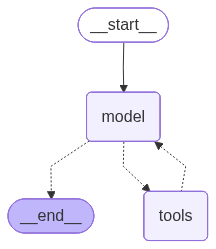

In [33]:
my_agent=create_agent(llm_bind, tools=tool_kit)
my_agent

In [34]:
my_agent.invoke(
{"messages":[{"role": "user", "content":"what is the education of person name is junaid whose location is Germany and bilal is public figure and work as IT}"
}]})

{'messages': [HumanMessage(content='what is the education of person name is junaid whose location is Germany and bilal is public figure and work as IT}', additional_kwargs={}, response_metadata={}, id='dca751ae-56a7-42ba-b80b-3bfcac8e8001'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 313, 'total_tokens': 413, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Dtd8QdIgYQoZfUiC3Anc5JHHZ7Xmc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef077-d6cc-7da3-9608-867ee838e4c9-0', tool_calls=[{'name': 'tool_peroanl_info', 'args': {'query': 'junaid location Germany; bilal public figure work IT

In [35]:
from langchain_core.messages import HumanMessage

my_agent.invoke({
    "messages": [HumanMessage(content="WHAT IS THE EDUCATION OF BILAL")]
})

{'messages': [HumanMessage(content='WHAT IS THE EDUCATION OF BILAL', additional_kwargs={}, response_metadata={}, id='fac1ffb2-2d33-4c43-bfd7-f81b1ad980fd'),
  AIMessage(content='Which Bilal do you mean? There are many people named Bilal (for example Bilal ibn Rabah, the early Muslim companion; Bilal Sayeed Oliver, the American singer; Bilal Erdoğan, etc.). Please give a full name or some context (profession, country, or a link), and tell me whether you want formal schooling (degrees, schools) or general background. I can then look it up.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 479, 'prompt_tokens': 296, 'total_tokens': 775, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 384, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'cha

In [37]:

my_agent.invoke(
    {"messages": [{"role": "user", "content": "What's the age of Junaid?. Make tool calls if necessary."}]}
)

{'messages': [HumanMessage(content="What's the age of Junaid?. Make tool calls if necessary.", additional_kwargs={}, response_metadata={}, id='d2e5dcc1-86c4-4fe8-aacb-0a9d5434aaba'),
  AIMessage(content='Which Junaid do you mean? There are many people named Junaid (e.g., Junaid Jamshed, Junaid Khan, someone in your contacts). Please give a last name or some context (country, profession, or a link). I can then search public sources or a personal database.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 266, 'prompt_tokens': 301, 'total_tokens': 567, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Dtd9xjEYSAgbVLTl6a2LZRrWdxU0s', 'service_tier': 'default', 'finish_reason': 'st